In [1]:
import sys
import os
import matplotlib.pyplot as plt
# Add the project root to the Python path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from crater_analysis.io import read_crater_locations, read_dem
from crater_analysis.analysis import filter_craters, get_crater_profile, get_dem_snippet
from crater_analysis.plotting import plot_dem, plot_crater_locations
from crater_analysis.core import Crater


dem, metadata = read_dem('../data/dems/LDEM_85S_40M.JP2')
craters = read_crater_locations('../data/catalogs/lunar_crater_database_robbins_2018.csv')
craters = filter_craters(craters, pole='south', lat_threshold=86, circ_threshold=None, diam_min=8, diam_max=None, lat_col='LAT_CIRC_IMG', diam_col='DIAM_CIRC_IMG')
craters.head()

Successfully read DEM from ../data/dems/LDEM_85S_40M.JP2
Successfully read 1296796 crater locations from ../data/catalogs/lunar_crater_database_robbins_2018.csv
Filtered to 58 craters matching criteria.


,CRATER_ID,LAT_CIRC_IMG,LON_CIRC_IMG,LAT_ELLI_IMG,LON_ELLI_IMG,DIAM_CIRC_IMG,DIAM_CIRC_SD_IMG,DIAM_ELLI_MAJOR_IMG,DIAM_ELLI_MINOR_IMG,DIAM_ELLI_ECCEN_IMG,...,DIAM_ELLI_ANGLE_IMG,LAT_ELLI_SD_IMG,LON_ELLI_SD_IMG,DIAM_ELLI_MAJOR_SD_IMG,DIAM_ELLI_MINOR_SD_IMG,DIAM_ELLI_ANGLE_SD_IMG,DIAM_ELLI_ECCEN_SD_IMG,DIAM_ELLI_ELLIP_SD_IMG,ARC_IMG,PTS_RIM_IMG
1176896,10-1-000837,-87.1809,84.5234,-87.1808,84.5604,44.1737,0.848881,44.8876,43.2854,0.264789,...,139.4290,0.001262,0.028222,0.093130,0.100417,2.93090,0.010930,0.003227,0.914110,390
1176897,10-1-000838,-88.0787,47.5154,-88.1028,47.0057,53.2922,0.725789,54.2819,50.9662,0.344139,...,168.3250,0.002928,0.075877,0.122559,0.226717,2.31280,0.012779,0.005313,0.553601,254
1176898,10-1-000839,-88.5073,352.0240,-88.4791,352.0430,21.9252,0.258503,22.2378,18.9305,0.524722,...,178.6140,0.000974,0.013294,0.023288,0.102322,0.67122,0.007604,0.006468,0.348900,67
1176899,10-1-000840,-88.4964,270.7200,-88.4961,270.7250,33.0960,0.692892,34.1718,31.9265,0.356499,...,15.1533,0.001455,0.058249,0.115068,0.110264,2.24557,0.011811,0.005163,0.985473,278
1176910,10-1-000851,-86.2959,284.8490,-86.2960,284.8490,12.3587,0.245685,12.8332,11.8834,0.377549,...,149.7540,0.000579,0.009257,0.044812,0.042061,2.16477,0.011292,0.005369,0.981986,128


In [2]:
### Initialise Craters ###
# Create an empty list to hold the Crater objects
crater_objects = []

# Loop through the first few rows of the DataFrame for demonstration
# To process all craters, change `craters.head(1).iterrows()` to `craters.iterrows()`
for index, row in craters.head(1).iterrows():
    # Extract crater properties from the row
    crater_id = row['CRATER_ID']
    crater_lon = row['LON_ELLI_IMG']
    crater_lat = row['LAT_ELLI_IMG']
    crater_diam_km = row['DIAM_ELLI_MAJOR_IMG'] #/1000.0  # Convert diameter from meters to kilometers
    
    # Get the DEM snippet for this crater
    dem_snippet, snippet_meta, center_coords = get_dem_snippet(
        dem,
        metadata,
        crater_lon,
        crater_lat,
        crater_diam_km
    )
    
    # Create the Crater object
    crater_obj = Crater(
        crater_id=crater_id,
        dem_snippet=dem_snippet,
        metadata=snippet_meta,
        center_coords=center_coords,
        global_coords={'lon': crater_lon, 'lat': crater_lat}
    )
    
    # Add the new object to our list
    crater_objects.append(crater_obj)

# Print a summary to confirm it worked
print(f"Successfully initialized {len(crater_objects)} Crater objects.")
if crater_objects:
    print("First crater object in the list:")
    print(crater_objects[0])
    print(crater_objects[0].dem_data)
print(dem)

Successfully initialized 1 Crater objects.
First crater object in the list:
Crater(id=10-1-000837, center=(841.3612775662104, 841.994648613243), global_coords={'lon': 84.5604, 'lat': -87.1808}, properties=[])
[[-7682 -7681 -7677 ...    33    37    36]
 [-7683 -7682 -7680 ...    35    38    36]
 [-7685 -7683 -7681 ...    34    39    41]
 ...
 [-3493 -3489 -3486 ... -2146 -2149 -2149]
 [-3497 -3491 -3487 ... -2156 -2154 -2152]
 [-3500 -3492 -3488 ... -2161 -2161 -2160]]
[[-1296 -1300 -1304 ... -3849 -3853 -3857]
 [-1298 -1301 -1306 ... -3856 -3857 -3858]
 [-1302 -1303 -1307 ... -3862 -3861 -3861]
 ...
 [-5982 -5984 -5987 ... -5393 -5391 -5390]
 [-5981 -5983 -5985 ... -5387 -5385 -5385]
 [-5979 -5981 -5983 ... -5382 -5383 -5380]]


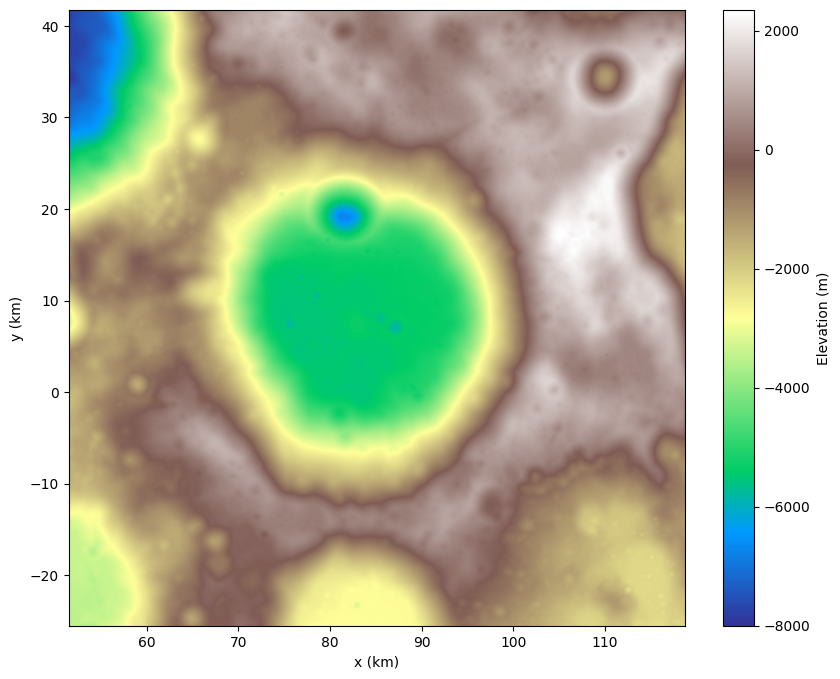

(<Figure size 1000x800 with 2 Axes>, <Axes: xlabel='x (km)', ylabel='y (km)'>)

In [3]:
plot_dem(crater_objects[0].dem_data, crater_objects[0].metadata)